In [ ]:
import os
import tarfile
import json
import io
from pathlib import Path

def create_clip_webdataset(root_dir, output_filename):
    root_path = Path(root_dir)
    # Get all ingredient folders (ignoring hidden files)
    ingredient_folders = [f for f in root_path.iterdir() if f.is_dir()]
    
    with tarfile.open(output_filename, "w") as tar:
        count = 0
        for folder in ingredient_folders:
            ingredient_name = folder.name
            # Path to the thumbs directory
            thumbs_path = folder / "thumbs"
            
            if not thumbs_path.exists():
                continue
                
            for img_path in thumbs_path.glob("*"):
                if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.webp']:
                    continue
                
                # Create a unique basename for this sample
                basename = f"{count:06d}"
                
                # 1. Add Image File
                tar.add(img_path, arcname=f"{basename}{img_path.suffix}")
                
                # 2. Add Metadata (JSON) for Prompt Ensembling
                # We store the raw ingredient and a few pre-generated prompts
                metadata = {
                    "ingredient": ingredient_name,
                    "prompts": [
                        f"a photo of {ingredient_name}",
                        f"a close-up shot of {ingredient_name}",
                        f"fresh {ingredient_name} for cooking",
                        f"an image of the ingredient {ingredient_name}",
                        f"a photo of raw {ingredient_name}",
                        f"{ingredient_name} on a white background",
                        f"fresh {ingredient_name} on a cutting board",
                        f"{ingredient_name} at a grocery store",
                        f"a high quality photo of {ingredient_name}"
                    ]
                }
                json_data = json.dumps(metadata).encode('utf-8')
                json_info = tarfile.TarInfo(name=f"{basename}.json")
                json_info.size = len(json_data)
                tar.addfile(json_info, io.BytesIO(json_data))
                
                count += 1
                if count % 100 == 0:
                    print(f"Packed {count} images...")

# Usage
create_clip_webdataset("./saved_pages", "ingredients_data.tar")

FileNotFoundError: [Errno 2] No such file or directory: 'saved_pages'

## Using .tar file with CLIP and Prompt Ensembling

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-rksody4g
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-rksody4g
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=b90ff47c3452f522fd912bcbff0a4c872150f7f92b32bdcd8e5b22e51751962e
  Stored in directory: /tmp/pip-ephem-wheel-cache-hlb7b7bs/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [3]:
pip install ftfy

In [4]:
pip install webdataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.4 MB/s eta 0:00:00


In [6]:
import torch
import clip
import webdataset as wds

# 1. Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# ==========================================
# THE FIX: Apply preprocess in the pipeline
# ==========================================
dataset = (
    wds.WebDataset("/content/drive/My Drive/Colab Notebooks/ingredients_data.tar")
    .decode("pil") 
    .to_tuple("jpg;png;webp", "json") 
    # Map 'preprocess' to the 1st item (image), and a dummy lambda to the 2nd item (metadata)
    .map_tuple(preprocess, lambda meta: meta) 
)

# Now it works! The DataLoader receives [3, 224, 224] Tensors and can stack them.
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32)

# ==========================================
# UPDATE: Accept 'prompts' directly
# ==========================================
def ensemble_inference(image_tensor, prompts):
    image_input = image_tensor.unsqueeze(0).to(device)
    
    # We pass the extracted prompts list directly here
    text_inputs = clip.tokenize(prompts).to(device)
    
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_inputs)
        
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        mean_text_feature = text_features.mean(dim=0, keepdim=True)
        mean_text_feature /= mean_text_feature.norm(dim=-1, keepdim=True)
        
        similarity = (100.0 * image_features @ mean_text_feature.T)
        
    return similarity

# ==========================================
# THE FIX: Extracting from Dictionary of Lists
# ==========================================
for batched_imgs, batched_meta in dataloader:
    
    # 1. Get the ingredient name for the first image in the batch
    ingredient_0 = batched_meta['ingredient'][12]
    
    # 2. Extract the prompts for the first image. 
    # Because PyTorch transposed the lists, we use a quick list comprehension 
    # to grab the 0th item from each transposed tuple.
    prompts_0 = [prompt_tuple[12] for prompt_tuple in batched_meta['prompts']]
    
    # 3. Run the inference
    score = ensemble_inference(batched_imgs[12], prompts_0)
    
    print(f"Confidence score for {ingredient_0}: {score.item():.2f}")
    break

100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 52.8MiB/s]
/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


Confidence score for abalone: 38.25


In [5]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/canonical_ingredients.csv")

In [12]:
# A list of all possible ingredients in your app
import random

all_categories = list(df["canonical_ingredient"].unique()) # add all 12

def predict_ingredient(image_tensor):
    image_input = image_tensor.unsqueeze(0).to(device)
    
    # Create a basic prompt for EVERY category
    text_prompts = [f"a photo of {cat}" for cat in all_categories]
    text_inputs = clip.tokenize(text_prompts).to(device)
    
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_inputs)
        
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Calculate similarity against ALL prompts at once
        similarity = (100.0 * image_features @ text_features.T)
        
        # Use Softmax to turn the raw scores into percentages that add up to 100%
        probabilities = similarity.softmax(dim=-1).cpu().numpy()[0]
    
    # Find the index of the highest probability
    best_index = probabilities.argmax()
    predicted_ingredient = all_categories[best_index]
    confidence = probabilities[best_index] * 100
    
    return predicted_ingredient, confidence

# Test it in your loop
for batched_imgs, batched_meta in dataloader:
    val = random.randint(0, len(all_categories))  # Randomly select an index in the batch
    actual_ingredient = batched_meta['ingredient'][0]
    prediction, confidence = predict_ingredient(batched_imgs[0])
    
    print(f"Actual: {actual_ingredient}")
    print(f"Predicted: {prediction} (Confidence: {confidence:.1f}%)")
    break

Actual: abalone
Predicted: abalone (Confidence: 27.2%)


In [19]:
import torch
import clip
import webdataset as wds
from collections import defaultdict

# --- 1. Setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval() # Crucial: Put model in evaluation mode

# Your list of all possible categories
all_categories = list(df['canonical_ingredient'].unique()) # Add all 12

dataset = (
    wds.WebDataset("/content/drive/My Drive/Colab Notebooks/ingredients_data.tar")
    .decode("pil")
    .to_tuple("jpg;png;webp", "json")
    .map_tuple(preprocess, lambda meta: meta)
)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32)

# --- 2. Pre-Compute Text Features (Massive Speedup) ---
print("Pre-computing text embeddings...")
text_prompts = [f"a photo of {cat.replace('_', ' ')}" for cat in all_categories]
print(text_prompts) # Debug: Check the generated prompts
text_inputs = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# --- 3. Tracking Variables ---
correct = 0
total = 0
total_confidence = 0.0

# Dictionary to track correct/total per class
# Looks like: {'spinach': {'correct': 5, 'total': 10}, ...}
class_stats = defaultdict(lambda: {'correct': 0, 'total': 0})

# --- 4. The Evaluation Loop ---
print("Running evaluation over dataset...")
with torch.no_grad():
    for batched_imgs, batched_meta in dataloader:
        
        # 1. Move images to GPU and extract true labels
        images = batched_imgs.to(device)
        true_labels = batched_meta['ingredient'] # This is a tuple of strings
        
        # 2. Get Image Features
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # 3. Calculate similarities for the whole batch at once
        similarity = (100.0 * image_features @ text_features.T)
        probabilities = similarity.softmax(dim=-1)
        
        # 4. Get the top prediction and confidence for each image in the batch
        max_probs, predicted_indices = probabilities.max(dim=1)
        
        # 5. Tally the results
        for i in range(len(true_labels)):
            true_label = true_labels[i]
            pred_label = all_categories[predicted_indices[i]]
            conf = max_probs[i].item() * 100
            
            total += 1
            total_confidence += conf
            class_stats[true_label]['total'] += 1
            
            if true_label == pred_label:
                correct += 1
                class_stats[true_label]['correct'] += 1

# --- 5. Generate The Report ---
overall_acc = (correct / total) * 100
mean_conf = total_confidence / total

print("\n" + "="*50)
print(" 📊 ZERO-SHOT CLASSIFICATION REPORT")
print("="*50)
print(f" Total Images Tested : {total}")
print(f" Overall Accuracy    : {overall_acc:.2f}%")
print(f" Mean Confidence     : {mean_conf:.2f}%")
print("-" * 50)

# Calculate accuracy per class and sort them to find the best
class_accuracies = []
for ingredient, stats in class_stats.items():
    if stats['total'] > 0:
        acc = (stats['correct'] / stats['total']) * 100
        class_accuracies.append((ingredient, acc, stats['total']))

# Sort by accuracy (highest first)
class_accuracies.sort(key=lambda x: x[1], reverse=True)

print(" Top Performing Classes:")
for i, (ingredient, acc, count) in enumerate(class_accuracies[:5]): # Show top 5
    print(f"  {i+1}. {ingredient.capitalize():<15} : {acc:>6.2f}%  ({count} images)")

print("\n Lowest Performing Classes:")
for i, (ingredient, acc, count) in enumerate(reversed(class_accuracies[-5:])): # Show bottom 5
    print(f"  {i+1}. {ingredient.capitalize():<15} : {acc:>6.2f}%  ({count} images)")

/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


Pre-computing text embeddings...
['a photo of abalone', 'a photo of adzuki beans', 'a photo of agave', 'a photo of aioli', 'a photo of alfredo sauce', 'a photo of all-purpose flour', 'a photo of allspice', 'a photo of almond butter', 'a photo of almond flour', 'a photo of almonds', 'a photo of amaranth', 'a photo of amaretto', 'a photo of american cheese', 'a photo of anchovy', 'a photo of anchovy paste', 'a photo of andouille', 'a photo of angel hair pasta', 'a photo of anise', 'a photo of annatto', 'a photo of apple', 'a photo of apple cider vinegar', 'a photo of apple juice', 'a photo of apricot', 'a photo of arrowroot', 'a photo of artichoke', 'a photo of artichoke hearts', 'a photo of arugula', 'a photo of asparagus', 'a photo of avocado', 'a photo of avocado oil', 'a photo of bacon', 'a photo of baguette', 'a photo of baking powder', 'a photo of baking soda', 'a photo of balsamic vinegar', 'a photo of bamboo shoots', 'a photo of banana', 'a photo of barbecue sauce', 'a photo of b

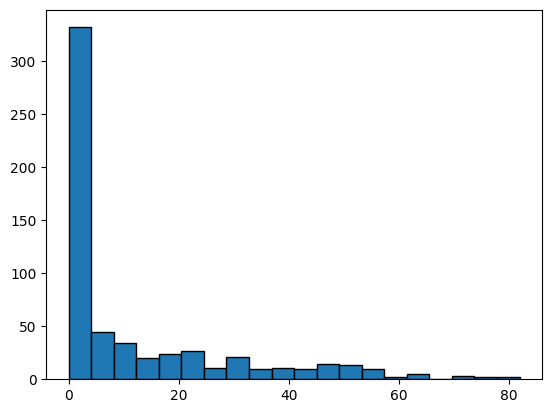

In [21]:
import matplotlib.pyplot as plt

plt.hist([acc for _, acc, _ in class_accuracies], bins=20, edgecolor='black')
plt.show()

In [24]:
import torch
import clip
import webdataset as wds
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

# --- CONFIGURATION ---
INPUT_TAR = "/content/drive/My Drive/Colab Notebooks/ingredients_data.tar"
CLEAN_TAR = "/content/drive/My Drive/Colab Notebooks/ingredients_clean.tar"
TOP_K_PER_CLASS = 150 # How many images to keep per ingredient

# Your list of all possible categories
all_categories = list(df['canonical_ingredient'].unique()) # Add all
# FIX: Clean the underscores for the text encoder
text_prompts = [f"a photo of {cat.replace('_', ' ')}" for cat in all_categories]

# Pre-compute text features
print("Pre-computing text embeddings...")
text_inputs = clip.tokenize(text_prompts).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# --- PASS 1: SCORING ---
print("Pass 1: Scoring all images...")

# We map a custom function to get the key, image, and metadata
def preprocess_with_key(sample):
    img_tensor = preprocess(sample["jpg"]) # Or "png", "webp" depending on your data
    return sample["__key__"], img_tensor, sample["json"]

scoring_dataset = wds.WebDataset(INPUT_TAR).decode("pil").map(preprocess_with_key)
dataloader = torch.utils.data.DataLoader(scoring_dataset, batch_size=32, num_workers=0)

# Dictionary to hold scores: {'spinach': [('key1', 85.2), ('key2', 12.4)]}
class_scores = defaultdict(list)

with torch.no_grad():
    for keys, images, metadata in dataloader:
        images = images.to(device)
        true_labels = metadata['ingredient']
        
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # We only care about the score for the TRUE label here
        for i in range(len(keys)):
            true_label = true_labels[i]
            # Find the index of this label in our category list
            try:
                class_idx = all_categories.index(true_label)
                # Calculate similarity specifically against the correct text prompt
                score = (100.0 * image_features[i] @ text_features[class_idx]).item()
                class_scores[true_label].append((keys[i], score))
            except ValueError:
                continue # Skip if label isn't in our master list

# --- FILTERING LOGIC ---
print(f"Filtering down to Top {TOP_K_PER_CLASS} per class...")
allowed_keys = set()

for ingredient, scores in class_scores.items():
    # Sort by score descending
    scores.sort(key=lambda x: x[1], reverse=True)
    # Grab the keys for the top K
    top_keys = [item[0] for item in scores[:TOP_K_PER_CLASS]]
    allowed_keys.update(top_keys)

print(f"Total images selected for clean dataset: {len(allowed_keys)}")

# --- PASS 2: WRITING ---
print("Pass 2: Writing clean dataset to disk...")

# For Pass 2, we do NOT decode. We just read the raw bytes and write them back.
raw_dataset = wds.WebDataset(INPUT_TAR)

with wds.TarWriter(CLEAN_TAR) as sink:
    written_count = 0
    for sample in raw_dataset:
        if sample["__key__"] in allowed_keys:
            sink.write(sample)
            written_count += 1
            if written_count % 1000 == 0:
                print(f"Written {written_count} images...")

print("Dataset cleaning complete!")

Pre-computing text embeddings...
Pass 1: Scoring all images...


/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


Filtering down to Top 150 per class...
Total images selected for clean dataset: 49650
Pass 2: Writing clean dataset to disk...
Written 1000 images...
Written 2000 images...
Written 3000 images...
Written 4000 images...
Written 5000 images...
Written 6000 images...
Written 7000 images...
Written 8000 images...
Written 9000 images...
Written 10000 images...
Written 11000 images...
Written 12000 images...
Written 13000 images...
Written 14000 images...
Written 15000 images...
Written 16000 images...
Written 17000 images...
Written 18000 images...
Written 19000 images...
Written 20000 images...
Written 21000 images...
Written 22000 images...
Written 23000 images...
Written 24000 images...
Written 25000 images...
Written 26000 images...
Written 27000 images...
Written 28000 images...
Written 29000 images...
Written 30000 images...
Written 31000 images...
Written 32000 images...
Written 33000 images...
Written 34000 images...
Written 35000 images...
Written 36000 images...
Written 37000 imag

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import clip
import webdataset as wds
import math

# --- 1. SETUP & MODEL LOADING ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model (jit=False is required to manipulate weights)
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model.train()

# ==========================================
# FIX 1: The GradScaler for AMP
# This dynamically scales gradients to prevent FP16 underflow (nan)
# ==========================================
scaler = torch.cuda.amp.GradScaler()

optimizer = optim.AdamW(model.parameters(), lr=5e-6, weight_decay=0.1)

# ==========================================
# FIX 2: Linear Warmup Scheduler
# Gently ramps up the learning rate from 0 to 5e-6 over the first 200 batches
# ==========================================
def warmup_rule(step):
    warmup_steps = 200
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    return 1.0 # Stay at 100% of base LR after warmup

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_rule)

# Loss functions
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

# --- 2. DATASET PIPELINE ---
CLEAN_TAR = "/content/drive/My Drive/Colab Notebooks/ingredients_clean.tar"

dataset = (
    wds.WebDataset(CLEAN_TAR)
    .decode("pil")
    .to_tuple("jpg;png;webp", "json")
    .map_tuple(preprocess, lambda meta: meta)
)

BATCH_SIZE = 64 
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=0)

# --- 3. TRAINING LOOP ---
epochs = 5

for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    running_loss = 0.0
    
    for batch_idx, (images, metadata) in enumerate(dataloader):
        optimizer.zero_grad()
        
        images = images.to(device)
        batch_prompts = [f"a photo of {cat.replace('_', ' ')}" for cat in metadata['ingredient']]
        texts = clip.tokenize(batch_prompts).to(device)
        
        # ==========================================
        # FIX 1 (Continued): Autocast Context Manager
        # Runs the forward pass in mixed precision safely
        # ==========================================
        with torch.cuda.amp.autocast():
            logits_per_image, logits_per_text = model(images, texts)
            
            current_batch_size = images.shape[0]
            ground_truth = torch.arange(current_batch_size, dtype=torch.long, device=device)
            
            total_loss = (
                loss_img(logits_per_image, ground_truth) + 
                loss_txt(logits_per_text, ground_truth)
            ) / 2
        
        # ==========================================
        # FIX 1 (Continued): Safe Backward Pass
        # ==========================================
        scaler.scale(total_loss).backward()
        
        # Unscale gradients before clipping so the clipping threshold is accurate
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Step the optimizer and update the scaler
        scaler.step(optimizer)
        scaler.update()
        
        # Step the warmup scheduler
        scheduler.step()
        
        # ==========================================
        # FIX 3: Clamp the Logit Scale
        # Prevents the temperature parameter from shooting to infinity.
        # math.log(100) ≈ 4.6052 (OpenAI's official safety limit)
        # ==========================================
        with torch.no_grad():
            model.logit_scale.clamp_(0, math.log(100))
        
        running_loss += total_loss.item()
        
        if batch_idx % 50 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Batch {batch_idx:4d} | Loss: {total_loss.item():.4f} | LR: {current_lr:.2e}")
            
    # Save a complete checkpoint (Model + Optimizer + Scaler + Scheduler)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss': running_loss
    }, f"/content/drive/My Drive/Colab Notebooks/clip_finetuned_epoch_{epoch+1}.pth")
    print(f"Saved Checkpoint for Epoch {epoch+1}")

print("Fine-tuning complete without exploding gradients!")

/tmp/ipykernel_12871/1353820032.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(



--- Epoch 1/5 ---


/tmp/ipykernel_12871/1353820032.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


Batch    0 | Loss: 5.3064 | LR: 2.50e-08


KeyboardInterrupt: 